In [1]:
import h5py
import scipy.io as sio 
import numpy as np
import matplotlib.pyplot as plt
from ptychozoon.enhance import ElementMap, FluorescenceDataset, Product, VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.settings import DeconvolutionEnhancementSettings
from ptychozoon.settings import InterpolationTypes
from chronos import plotting as tplot
from chronos.timer_utils import toggle_timer, clear_timer_globals
import logging

## Generate Data

### 1. Make ptycho array and fluorescence arrays

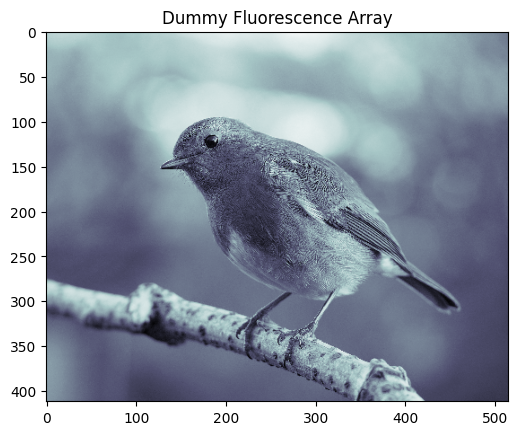

In [2]:
from PIL import Image
import numpy as np

img = Image.open("/local/Erithacus_rubecula_with_cocked_head.jpg")   # Load image
s = 5
sample_image = np.array(img).mean(2)[::s, ::s] * 1

plt.title("Dummy Fluorescence Array")
plt.imshow(sample_image, cmap="bone")
plt.show()

In [3]:
object_size = sample_image.shape
padding = 64
element_maps_truth = [ElementMap(name="rubecula", counts_per_second=sample_image)]

### 2. Make probe positions

Grid: 149 rows x 202 cols = 30098 positions


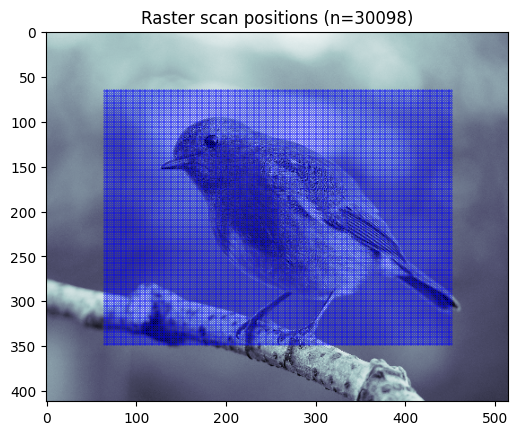

In [4]:
# Raster scan positions covering the area 'padding' pixels from the object edge
n_positions = 30e3  # approximate total; actual count = n_rows * n_cols

scan_row_min = padding
scan_row_max = object_size[0] - padding
scan_col_min = padding
scan_col_max = object_size[1] - padding

scan_height = scan_row_max - scan_row_min
scan_width  = scan_col_max - scan_col_min

# Grid dimensions that preserve the scan area aspect ratio
aspect = scan_height / scan_width
n_cols = max(1, int(np.round(np.sqrt(n_positions / aspect))))
n_rows = max(1, int(np.round(n_positions / n_cols)))

row_coords = np.linspace(scan_row_min, scan_row_max, n_rows)
col_coords = np.linspace(scan_col_min, scan_col_max, n_cols)

# Raster scan: all rows go left to right
positions = np.array([
    [r, c]
    for r in row_coords
    for c in col_coords
])  # shape: (n_rows * n_cols, 2)  —  axis 0 = row, axis 1 = col (pixels)

print(f"Grid: {n_rows} rows x {n_cols} cols = {len(positions)} positions")

# Visualise scan path overlaid on the object phase
plt.figure()
plt.imshow(element_maps_truth[0].counts_per_second, cmap="bone", origin="upper")
plt.plot(positions[:, 1], positions[:, 0], ".b", lw=0.5, alpha=1, ms=.5)
plt.title(f"Raster scan positions (n={len(positions)})")
plt.show()

### 3. Make probe

Probe FWHM: 19.79898987322333


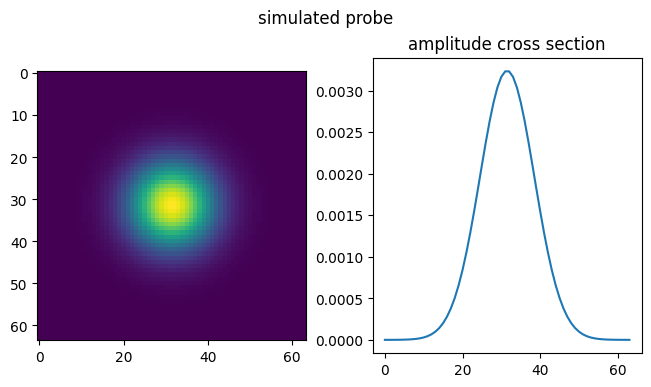

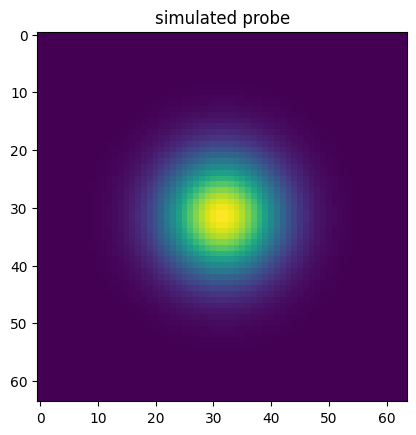

In [5]:
# Generate complex Gaussian probe
probe_size = (padding, padding)
probe_width = 7  # Gaussian sigma in pixels (user-settable)
print(f"Probe FWHM: {probe_width * 2 * np.sqrt(2*np.log2(2))}")

# Coordinate grids centred on zero
y = np.linspace(-(probe_size[0] - 1) / 2, (probe_size[0] - 1) / 2, probe_size[0])
x = np.linspace(-(probe_size[1] - 1) / 2, (probe_size[1] - 1) / 2, probe_size[1])
Y, X = np.meshgrid(y, x, indexing="ij")

probe = np.exp(-(X**2 + Y**2) / (2 * probe_width**2)).astype(np.complex128)
probe /= np.sqrt(np.sum(np.abs(probe) ** 2))  # normalise to unit energy
probe /= np.abs(probe).sum()

fig, ax = plt.subplots(1, 2, layout="compressed")
fig.suptitle("simulated probe")
plt.sca(ax[0])
plt.imshow(np.abs(probe))
plt.sca(ax[1])
plt.title("amplitude cross section")
plt.plot(np.abs(probe)[padding//2])
# plt.axis("off")
plt.show()

plt.title("simulated probe")
plt.imshow(np.abs(probe))
plt.show()

### 4. Get convolved XRF arrays
i.e. simulate XRF measurement

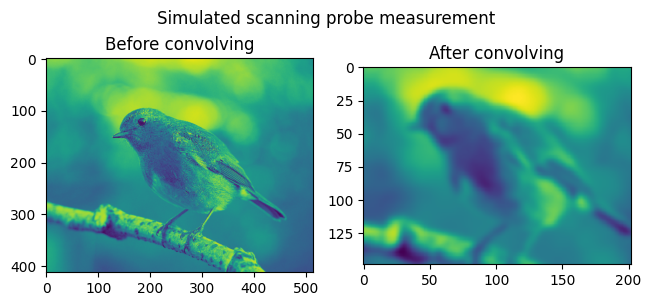

In [6]:
from scipy.signal import fftconvolve

# Use probe intensity (|probe|^2) as PSF, matching the forward model in enhance.py
probe_intensity = np.abs(probe) ** 2
probe_intensity = probe_intensity / probe_intensity.sum()

# Convolve full object with probe PSF, then sample at scan positions.
# conv_result[r, c] = integral of PSF * element_map_patch centred at (r, c)
element_maps_convolved = []
for element_map in element_maps_truth:
    conv_result = fftconvolve(element_map.counts_per_second, probe_intensity, mode="same")

    # Sample at each scan position (positions are already integer-valued from linspace,
    # but round to be safe)
    pos_idx = np.round(positions).astype(int)
    measurements_flat = conv_result[pos_idx[:, 0], pos_idx[:, 1]]

    # Reshape to (n_rows, n_cols). Raster scan order matches probe_positions order,
    # so this is directly visualizable.
    measurements = np.abs(measurements_flat.reshape(n_rows, n_cols))

    fig, ax = plt.subplots(1, 2, layout="compressed")
    plt.sca(ax[0])
    plt.title("Before convolving")
    plt.imshow(element_map.counts_per_second)#, aspect="auto")
    plt.sca(ax[1])
    plt.title("After convolving")
    ax[1].imshow(measurements)#, aspect="auto")
    plt.suptitle("Simulated scanning probe measurement")
    plt.show()

    element_maps_convolved += [ElementMap(element_map.name, measurements)]

### 5. Package data into `ptychozoon` objects

In [7]:
dummy_ptycho_object = np.zeros_like(element_maps_truth[0].counts_per_second, dtype=np.complex128)

In [8]:
# package data
# ptycho
pixel_size_m = 1
probe_positions = positions - np.array(dummy_ptycho_object.shape) / 2
# probe_positions += -np.array((probe.shape[0] / 2,) * 2)
ptycho_in = Product(
    probe_positions=probe_positions,
    probe=probe[None],
    object_array=dummy_ptycho_object,
    pixel_size_m=(pixel_size_m,) * 2,
    object_center_m=np.array([0, 0]),
)
# fluorescence
flourescence_in = FluorescenceDataset(element_maps_convolved)

# plt.imshow(np.angle(ptycho_in.object_array))
# plt.plot(
#     ptycho_in.probe_positions[:, 1] + object_array.shape[1] / 2,
#     ptycho_in.probe_positions[:, 0] + object_array.shape[0] / 2,
#     "k",
#     alpha=0.25,
# )
# plt.show()


## Run enhancement

### Define results plotting functions

In [9]:
def plot_result_images(
    element_map_truth: ElementMap,
    element_map_input: ElementMap,
    element_map_enhanced: ElementMap,
):
    fig, ax = plt.subplots(1, 3, layout="compressed", figsize=(10, 10))
    plt.sca(ax[0])
    plt.title(f"{element_map_truth.name}\ntruth")
    plt.imshow(element_map_truth.counts_per_second, cmap="bone")
    # plt.colorbar()
    plt.sca(ax[1])
    plt.title(f"{element_map_input.name}\nconvolved")
    plt.imshow(element_map_input.counts_per_second, cmap="bone")
    # plt.colorbar()
    plt.sca(ax[2])
    plt.title(f"{element_map_enhanced.name}\nfluorescence-enhanced")
    plt.imshow(element_map_enhanced.counts_per_second, cmap="bone")
    # plt.colorbar()
    plt.show()

def plot_result_cross_sections(
    element_map_truth: ElementMap,
    element_map_input: ElementMap,
    element_map_enhanced: ElementMap,
    xrf_array_width_in_pixels: float,
):
    labels = ["convolved", "enhanced", "truth"]
    arrays_in = [
        element_map_input.counts_per_second,
        element_map_enhanced.counts_per_second,
        element_map_truth.counts_per_second,
    ]
    slice_idx = []
    lw=2
    fig, ax = plt.subplots(1, figsize=(4,4))
    for i, arr in enumerate(arrays_in):
        slice_idx = arr.shape[1]//2
        print(slice_idx)
        if i == 0:
            x = np.linspace(-xrf_array_width_in_pixels/2, xrf_array_width_in_pixels/2, len(arr[slice_idx]))
            plt.plot(x, arr[slice_idx], label=labels[i], lw=lw, alpha=1)
        elif i == 1:
            w0 = len(arr[slice_idx])
            x = np.linspace(-w0/2, w0/2, len(arr[slice_idx]))
            plt.plot(x, arr[slice_idx], label=labels[i], zorder=-4, alpha=1)
        elif i == 2:
            w0 = len(arr[slice_idx])
            x = np.linspace(-w0/2, w0/2, len(arr[slice_idx]))
            plt.plot(x, arr[slice_idx], label=labels[i], zorder=-5, color="k")
    plt.grid(ls=":", zorder=-99)
    # plt.autoscale(True, "x", True)
    plt.legend(fontsize=10)#, loc="lower right")
    plt.show()


### results: fourier

In [85]:
import importlib
import ptychozoon
importlib.reload(ptychozoon)
importlib.reload(ptychozoon.enhance)
importlib.reload(ptychozoon.settings)

from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.settings import DeconvolutionEnhancementSettings

In [ ]:
settings = DeconvolutionEnhancementSettings()
# settings.interpolation = InterpolationTypes.BARYCENTRIC
# settings.gpu.enabled = False
settings.interpolation = InterpolationTypes.FOURIER
settings.solver = "lsmr"
settings.lsmr.max_iter = 2
settings.lsmr.damping_factor = 0
settings.lsmr.atol = 0
settings.lsmr.btol = 0

# settings.solver = "minres"
# settings.lsmr.max_iter = 10
# settings.lsmr.damping_factor = 0.0

clear_timer_globals()
toggle_timer(True)
logging.basicConfig(level=logging.DEBUG)
flourescence_result, convolve_fit = VSPIFluorescenceEnhancingAlgorithm().enhance(
    flourescence_in,
    ptycho_in,
    settings=settings,
)
logging.basicConfig(level=logging.INFO)
convolve_fit = convolve_fit.reshape(flourescence_in.element_maps[0].counts_per_second.shape).get()
 
# A^T * u result gets worse on each iteration

  0%|          | 0/1 [00:00<?, ?it/s]INFO:ptychozoon.enhance:Enhancing "rubecula"...


DEBUG:ptychozoon.enhance:Result: (array([0., 0., 0., ..., 0., 0., 0.], shape=(212180,)), 7, 2, np.float64(1337.6634880742552), np.float64(317.75016233538946), np.float64(0.6489848225614198), np.float64(2.5301800737743876), 47803.927246810184)
DEBUG:ptychozoon.enhance:Number of iterations: 2
DEBUG:ptychozoon.enhance:norm(b-Ax): 1337.6634880742552
DEBUG:ptychozoon.enhance:norm(A^H (b - Ax)): 317.75016233538946
DEBUG:ptychozoon.enhance:norm(A)): 0.6489848225614198
INFO:ptychozoon.enhance:Enhanced "rubecula" in 0.4808 seconds.
100%|██████████| 1/1 [00:00<00:00,  2.07it/s]


- Sarah, ISN
- L1, L2
- tiff stack output, h5 output
- Look more at the VSPI paper


1 iterations
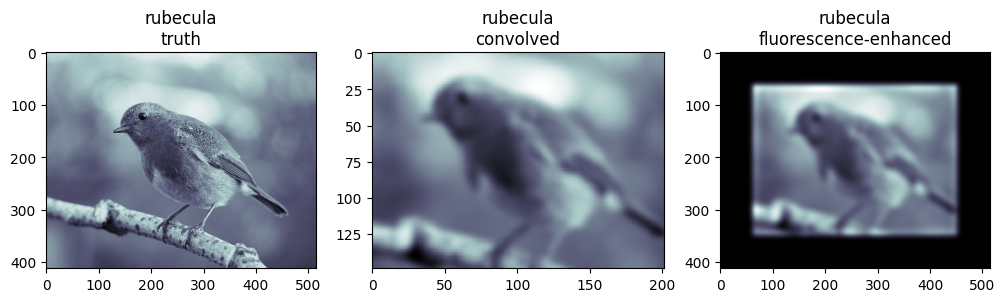

10 iterations
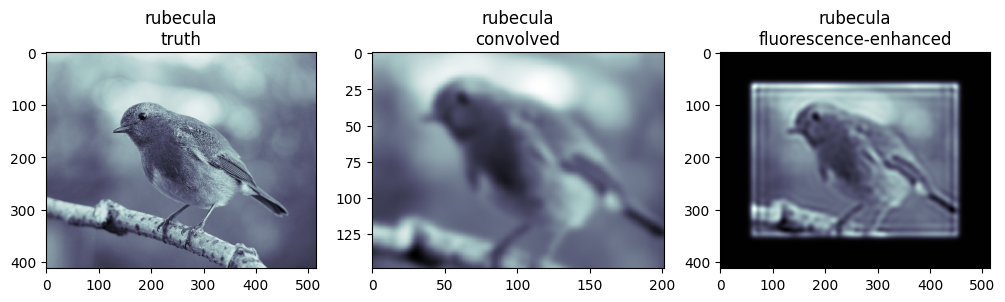

50 iterations
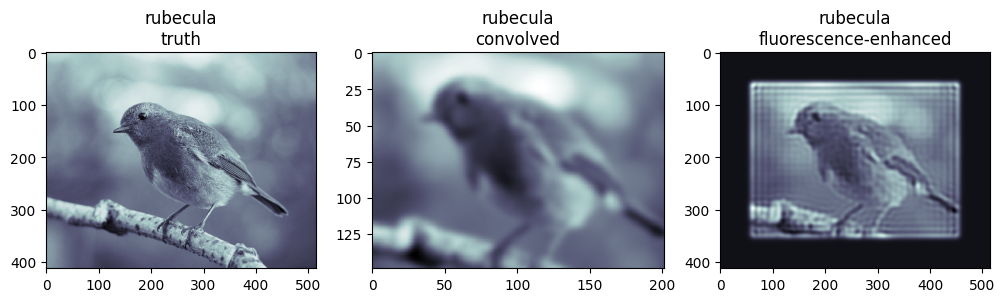

100 iterations
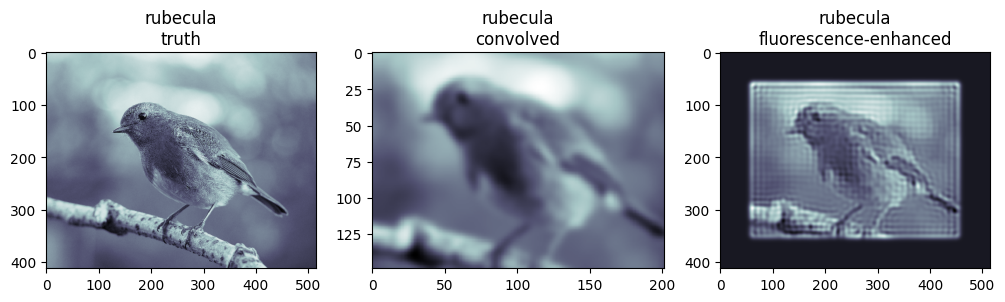

In [38]:
convolve_fit = convolve_fit.reshape(flourescence_in.element_maps[0].counts_per_second.shape)

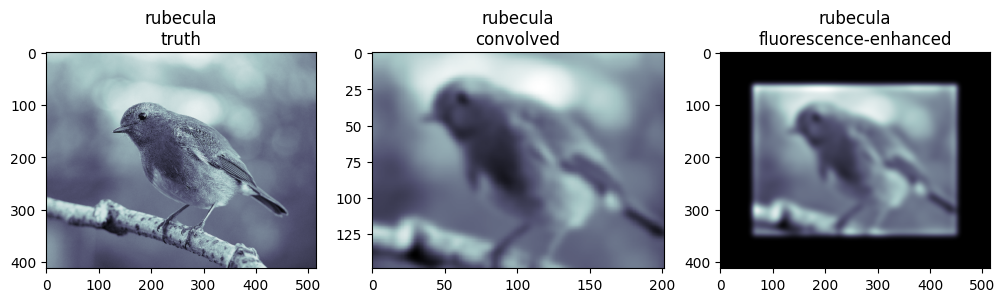

101
257
257


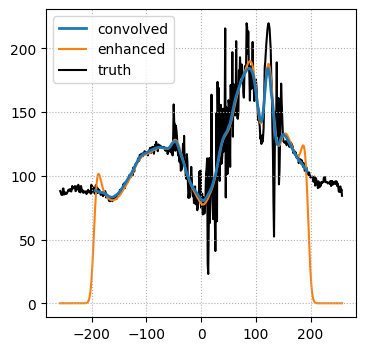

In [94]:
for i in range(len(flourescence_result.element_maps)):
    plot_result_images(
        element_maps_truth[i],
        flourescence_in.element_maps[i],
        flourescence_result.element_maps[i],
    )

    plot_result_cross_sections(
        element_maps_truth[i],
        flourescence_in.element_maps[i],
        flourescence_result.element_maps[i],
        xrf_array_width_in_pixels=col_coords[-1] - col_coords[0],
    )

In [48]:
(30e3*10e4)*1e-9

3.0


10 iter:
DEBUG:ptychozoon.enhance:norm(b-Ax): 269.61612275149486
DEBUG:ptychozoon.enhance:norm(A^H (b - Ax)): 16.623645872945527

100 iter:
DEBUG:ptychozoon.enhance:norm(b-Ax): 64.15452802710651
DEBUG:ptychozoon.enhance:norm(A^H (b - Ax)): 0.17767709318295552

b-Ax is calculated as b_meas - A * x_fit, where A * x_fit is calculated from matvec


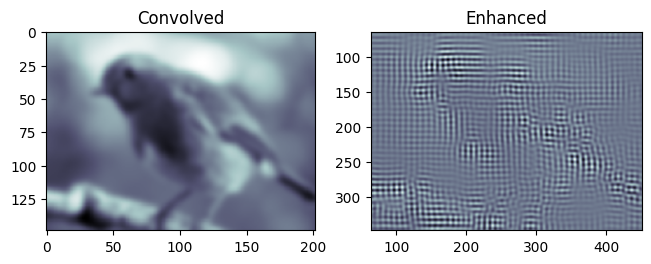

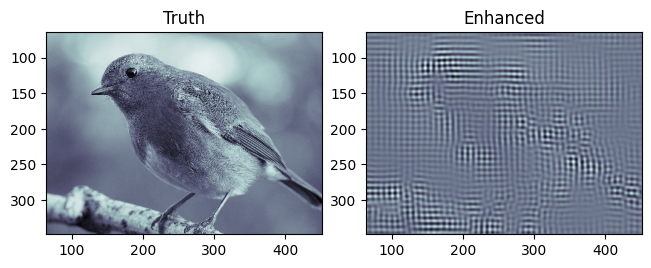

In [40]:
i=0
fig, ax = plt.subplots(1, 2, layout="compressed")
plt.sca(ax[0])
arr = flourescence_in.element_maps[i].counts_per_second
plt.imshow(arr, cmap="bone")
plt.title("Convolved")
plt.sca(ax[1])
plt.title("Enhanced")
arr = flourescence_result.element_maps[i].counts_per_second
plt.imshow(arr, cmap="bone")
plt.xlim([padding, arr.shape[1]-padding])
plt.ylim([arr.shape[0]-padding, padding])
plt.show()

i=0
fig, ax = plt.subplots(1, 2, layout="compressed")
plt.sca(ax[0])
arr = element_maps_truth[0].counts_per_second
plt.imshow(arr, cmap="bone")
plt.title("Truth")
plt.sca(ax[1])
plt.title("Enhanced")
arr = flourescence_result.element_maps[i].counts_per_second
plt.imshow(arr, cmap="bone")
for i in range(2):
    plt.sca(ax[i])
    plt.xlim([padding, arr.shape[1]-padding])
    plt.ylim([arr.shape[0]-padding, padding])
plt.show()

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x7f4718e02210>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x7f4718e02ba0>
DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x7f4718e03530>


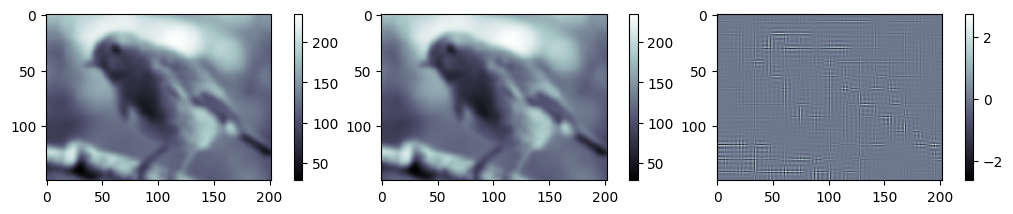

In [41]:
fig, ax = plt.subplots(1, 3, layout="compressed", figsize=(10,10))
plt.sca(ax[0])
# plt.title(r"Simulated convolution ($b_{meas}$)")
plt.imshow(flourescence_in.element_maps[0].counts_per_second, cmap="bone")
plt.sca(ax[1])
# plt.title(r"$b_{fit} = A  x_{enhanced}$")
plt.imshow(convolve_fit, cmap="bone")
plt.sca(ax[2])
# plt.title(r"$b_{fit} - b_{meas}$")
plt.imshow(convolve_fit - flourescence_in.element_maps[0].counts_per_second, cmap="bone")
for i in range(3):
    plt.sca(ax[i])
    plt.colorbar()
plt.show()


In [46]:
np.abs((convolve_fit - flourescence_in.element_maps[0].counts_per_second)).mean()

np.float64(0.15233617082607)

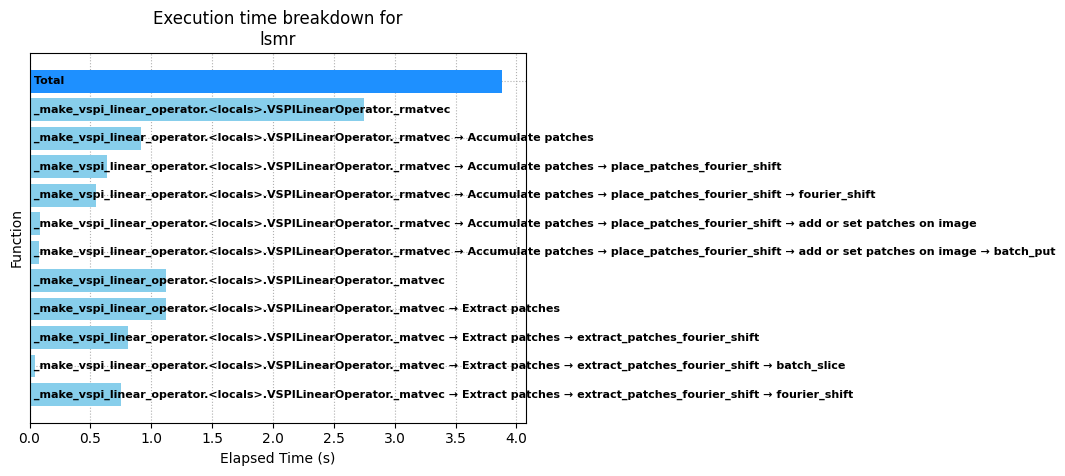

Execution summary of lsmr

Total execution time: 3.88 s

Execution times:
1. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec: 2.7 s
2. Accumulate patches: 0.92 s
3. place_patches_fourier_shift: 0.64 s
4. fourier_shift: 0.54 s
5. add or set patches on image: 0.082 s
6. batch_put: 0.081 s
7. _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec: 1.1 s
8. Extract patches: 1.1 s
9. extract_patches_fourier_shift: 0.81 s
10. batch_slice: 0.043 s
11. fourier_shift: 0.75 s

Function call stack info:
Ordered by time of first function call
1. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec
2. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Accumulate patches
3. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Accumulate patches → place_patches_fourier_shift
4. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Accumulate patches → place_patches_fourier_shift → fourier_shift
5. _make_vspi_linear_operator.<l

{'Total': np.float64(3.8810675144195557),
 '_make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec': np.float64(2.7491631507873535),
 'Accumulate patches': np.float64(0.9181809425354004),
 'place_patches_fourier_shift': np.float64(0.6385538578033447),
 'fourier_shift': np.float64(0.7538447380065918),
 'add or set patches on image': np.float64(0.08179473876953125),
 'batch_put': np.float64(0.08137631416320801),
 '_make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec': np.float64(1.121598243713379),
 'Extract patches': np.float64(1.1176447868347168),
 'extract_patches_fourier_shift': np.float64(0.8099794387817383),
 'batch_slice': np.float64(0.04285240173339844)}

In [84]:
logging.basicConfig(level=1)
tplot.plot_elapsed_time_bar_plot_advanced("lsmr", use_long_bar_labels=True)